# Generative AI Applications Project
* **Gene Foxwell**

## Overview

This project looks at how a Generative Pretrained Transformer Model (GPT) can be used to solve Reinforcement Learning Problems. The idea is based on the Decision Transformers paper ([PAPER](https://arxiv.org/abs/2106.01345)). We will use the Human Relocate Data from Minari's DR4RL section. Further information on the Relocate data can be found here ([PAPER](https://minari.farama.org/main/datasets/D4RL/relocate/)). The relocate problem was originally introduced here ([PAPER](https://arxiv.org/abs/1709.10087)). 

The basic problem is to train virtual 24 DoF robotic hand to pick up a ball from one location and move it to another.

We'll attack this problem in the following sequence:

* Build a GPT Model that we can use with a Decision Transformer.
* We'll build an implementation of the Decision Transformer Algorithm.
* We'll train the algorithm on the Human generated data for the Relocate the problem.
* Summary of results.

Let's get started...

## Transformer Model

We'll build our transformer model based on the architecture described in ([ATTENTION PAPER](https://arxiv.org/abs/1706.03762)) as well as examples from Udacity's course work.

The key idea behind the Transformer Model is the Attention Head. The basic idea is that it maps a set of Queries - which are effectively Key/Value pairs, onto an output. These are used to create a kind of weighted sum, which allows the block to determine which parts of the incoming sequence are "related" to each other.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from collections import deque

import minari
import gymnasium as gym
import gymnasium_robotics

import imageio
from IPython.display import Video


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


In [2]:
# Use CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(
            config["embed_dim"], config["head_size"], config["use_bias"]
        )
        self.K_weights = nn.Linear(
            config["embed_dim"], config["head_size"], config["use_bias"]
        )
        self.V_weights = nn.Linear(
            config["embed_dim"], config["head_size"], config["use_bias"]
        )

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(
            torch.ones(config["context_size"], config["context_size"])
        )
        self.register_buffer("casual_attention_mask", casual_attention_mask)

    def forward(self, input):  # (B, C, embedding_dim)
        batch_size, tokens_num, embedding_dim = input.shape
        Q = self.Q_weights(input)  # (B, C, head_size)
        K = self.K_weights(input)  # (B, C, head_size)
        V = self.V_weights(input)  # (B, C, head_size)

        # Matrix Multiplay Q x K transpose to get the dot product of the query vectors with the key vectors
        attention_scores = Q @ K.transpose(1, 2)  # (B, C, C)

        # scale attention scores, scalled by square root of the dimensionality of the key vectors
        attention_scores = attention_scores / (K.shape[-1] ** 0.5)
        
        # mask the attention scores
        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0, -torch.inf
        )

        # calculate softmax values
        attention_scores = torch.softmax(attention_scores, dim=-1)

        # apply dropout for regularization
        attention_scores = self.dropout(attention_scores)

        # multiply attention scores by the value function.
        return attention_scores @ V  # (B, C, head_size)

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()

        # initialize the individual AttentionHead objects
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        # Feedforward connection for after the attention heads
        self.linear = nn.Linear(config["embed_dim"], config["embed_dim"])

        # Dropout regularization.
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        # execute heads in ||
        heads_outputs = [head(input) for head in self.heads]

        # concatenate the outputs into a single tensor
        scores_change = torch.cat(heads_outputs, dim=-1)

        # run the results through a feed forward network.
        scores_change = self.linear(scores_change)

        # regularization and return results
        return self.dropout(scores_change)

In [5]:
class FeedForward(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.linear_layers = nn.Sequential(
            nn.Linear(config["embed_dim"], config["embed_dim"] * 4),
            nn.GELU(),
            nn.Linear(config["embed_dim"] * 4, config["embed_dim"]),
            nn.Dropout(config["dropout_rate"]),
        )

    def forward(self, input):
        return self.linear_layers(input)

In [6]:
class Block(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["embed_dim"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["embed_dim"])

    def forward(self, input):
        residual = input
        x = self.multi_head(self.layer_norm_1(input))
        x = x + residual

        residual = x
        x = self.feed_forward(self.layer_norm_2(x))
        return x + residual

In [7]:
class TransformerModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)
        self.layer_norm = nn.LayerNorm(config["embed_dim"])


    def forward(self, input_embeddings):
        """
        Forward step for the transformer model. The DecisionTransformer already handles embeddings and positional encodings.
        We are simply making predictions using the AttentionHeads and returning the final hidden layer.
        """
        
        # Pass the embeddings through the stacked Transformer blocks
        x = self.layers(input_embeddings)
        
        # Apply the final layer normalization
        return self.layer_norm(x)

## Decision Transformer

We'll base our implementation of the Decision Transformer based on the DecisionTransformer pseduo-code provided in the Decision Transformers paper.

Decision Transformer applies the Transformer Model to generate RL Policies. The idea here is that the Decision Transformer uses a sequence of states, actions, and rewards, to generate a sequence of actions to acheive some goal on the environment. In our case, we will be attempting to train the ADROIT Hand to pick up a ball and move it to a new location.

Our incoming sequences will be the the environmental observations, actions, and rewards received so far during the session. The Transformer will then autoregressively generate a sequence of actions. From an RL point of view, the Decision Transformer is acting as a kind of policy, mapping trajectories in the environment to actions.

In [8]:
class DecisionTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()

        # size of the hidden layer
        self.hidden_size = config["embed_dim"]

        # maximum number of timetimes in an episode
        max_ep_length = config["max_ep_length"]
        
        # dimension of the state space
        self.state_dim = config["state_dim"]

        # dimension of the action space.
        self.action_dim = config["action_dim"]

        # embedding layers for timestamps, returns, states, and actions (t,r,s,a)
        # remember, at each time timestamp, we have a triple:
        #   r = expected return
        #   s = state
        #   a = action
        self.embed_timestep = nn.Embedding(max_ep_length, self.hidden_size)
        self.embed_return = nn.Linear(1, self.hidden_size)
        self.embed_state = nn.Linear(self.state_dim, self.hidden_size)
        self.embed_action = nn.Linear(self.action_dim, self.hidden_size)

        # Normalization of the embedding layers
        self.embed_ln = nn.LayerNorm(self.hidden_size)
        
        # action prediction layer
        self.predict_action = nn.Linear(self.hidden_size, self.action_dim)

        # reward prediction layer
        self.predict_reward = nn.Linear(self.hidden_size, 1) # only one reward to predict at each time step, so output dimension is 1.

        # create an instance of the transformer model
        # this will be used to generate the next steps in the sequence.
        self.transformer = TransformerModel(config)

    def forward(self, states, actions, returns_to_go, timesteps):
        """
        Generate the next action using the previous Returns, States, Actions, and Timestamps.
        Based on the DecisionTransformer algorithm
        """
        batch_size, seq_length = states.shape[0], states.shape[1]
        
        pos_embedding = self.embed_timestep(timesteps)
        
        state_embeddings = self.embed_state(states) + pos_embedding
        action_embeddings = self.embed_action(actions) + pos_embedding
        returns_embeddings = self.embed_return(returns_to_go) + pos_embedding
        
        stacked_inputs = torch.stack(
            (returns_embeddings, state_embeddings, action_embeddings), dim=1
        ).permute(0, 2, 1, 3).reshape(batch_size, 3*seq_length, self.hidden_size)
        
        input_embeddings = self.embed_ln(stacked_inputs)
        
        hidden_states = self.transformer(input_embeddings)

        action_preds = torch.tanh(self.predict_action(hidden_states[:, 1::3, :]))
        reward_preds = self.predict_reward(hidden_states[:, 1::3, :]) # we are making predictions for a continious system with actions between [-1, 1]
        
        return action_preds, reward_preds

## ADROIT Hand Relocate Problem

We are focusing on the ADROIT Relocation problem. In this problem we will drain a robotic hand to find a ball, pick it up, and then drop it off at another location. We will train this hand using human generated data provided by Minari. Our agent will be based on the DecisionTransformer approach above - autoregressively outputing the policy needed to solve the environment.

Ultimately, we want to see how well the resulting Agent can generalize based on training from human data alone.

### Action Space

The ADROIT Hand has 24 Degrees of Freedom. The full action space is documented here: https://robotics.farama.org/envs/adroit_hand/adroit_relocate/

The action space has 30 dimensions. 24 dimensions for controlling the actuators of the hand, and 6 dimenions for controlling the position of the hand in the environment.

Inputs to the hands are scaled between to fall in the range [-1, 1]

### Observation Space

The observation space for this system has 39 dimenions. 30 dimensions for describing the state of the arms actuator and the position / rotatation of the arm itself. The final 9 dimensions describe the different in location between the palm of the hand and the ball, the palm of the hand and the target, and finally, the ball and the target. The observation space is documented here: https://robotics.farama.org/envs/adroit_hand/adroit_relocate/

### Minari RL Dataset

We will use the *human* generated data from the D4RL dataset's Relocate Problem. This dataset has 9942 training steps split over 25 training episodes. This data will be used to train the Decision Transformer using an "offline" training approach. We will then evaluate the resulting Decision Transformer on corresponding environment.

In [9]:
minari_dataset = minari.load_dataset('D4RL/relocate/human-v2', download=False)

In [10]:
print("Observation space:", minari_dataset.observation_space)
print("Action space:", minari_dataset.action_space)
print("Total episodes:", minari_dataset.total_episodes)
print("Total steps:", minari_dataset.total_steps)

Observation space: Box(-inf, inf, (39,), float64)
Action space: Box(-1.0, 1.0, (30,), float32)
Total episodes: 25
Total steps: 9942


### Human Training Examples

In [11]:
def visualize_human_example(dataset, episode_index=0, filename="video/human_behavior.mp4"):
    """
    Visualizes a specific human demonstration from the Minari dataset.
    
    Args:
        dataset: The loaded minari dataset (e.g., minari_dataset)
        episode_index: Which human episode to replay (0 to 24 for the human dataset)
        filename: Where to save the resulting MP4 video
    """
    env = dataset.recover_environment(render_mode="rgb_array")
    
    episodes = list(dataset.iterate_episodes())
    if episode_index >= len(episodes):
        print(f"Error: Episode index {episode_index} is out of bounds.")
        return
        
    episode = episodes[episode_index]
    print(f"Replaying human episode {episode_index} with {len(episode.actions)} steps...")
    
    env.reset()
    
    frames = []
    
    frames.append(env.render())
    
    for action in episode.actions:
        env.step(action)
        frames.append(env.render())
        
    env.close()
    
    imageio.mimsave(filename, frames, fps=30)
    print(f"Saved human demonstration video to {filename}")
    
    return Video(filename, embed=True)

In [12]:
visualize_human_example(minari_dataset, episode_index=22, filename="video/human_episode_22.mp4")

Replaying human episode 22 with 297 steps...
Saved human demonstration video to video/human_episode_22.mp4


In [13]:
visualize_human_example(minari_dataset, episode_index=5, filename="video/human_episode_05.mp4")

Replaying human episode 5 with 527 steps...
Saved human demonstration video to video/human_episode_05.mp4


In [14]:
visualize_human_example(minari_dataset, episode_index=16, filename="video/human_episode_16.mp4")

Replaying human episode 16 with 439 steps...
Saved human demonstration video to video/human_episode_16.mp4


In [15]:
def process_dataset(dataset=minari_dataset, rtg_scale=1.0):
    """
    Split the observed data into the states, actions, returns_to_go, and timestamps needed for the 
    DecisionTransformer algorithm.
    """
    episodes = list(dataset.iterate_episodes())
       
    states = []
    actions = []
    returns_to_go = []
    timesteps = []
    rewards_list = []
    

        
    for ep in episodes:  # Fix: changed self.episodes to episodes
        obs = ep.observations        
        acts = ep.actions 
        rews = ep.rewards
        
        rtg = np.zeros_like(rews)

        # Calculate the returns to go for each timestep
        for i in reversed(range(len(rews))):
            rtg[i] = rews[i] + (rtg[i+1] if i+1 < len(rews) else 0)
    
        rtg = rtg / rtg_scale

        states.append(obs)
        actions.append(acts)
        returns_to_go.append(rtg)
        
        # create the timesteps array for this episode
        timesteps.append(np.arange(len(rews)))

        rewards_list.append(rews)

    return states, actions, returns_to_go, timesteps, rewards_list

In [16]:
states, actions, returns_to_go, timestamps, rewards_list = process_dataset(
    dataset=minari_dataset,
    rtg_scale=3600
)

In [17]:
episode_returns = [rtg[0] for rtg in returns_to_go]
average_episode_reward = np.mean(episode_returns)
print(f"Average Reward per Episode: {average_episode_reward:.2f}")

Average Reward per Episode: 1.02


In [18]:
max_ep_length = max(len(acts) for acts in actions)
print(f"The maximum episode length is: {max_ep_length} steps")

min_episode_length = min(len(acts) for acts in actions)
print(f"The minimum episode length is: {min_episode_length} steps")

The maximum episode length is: 527 steps
The minimum episode length is: 297 steps


In [19]:
class ADROITHandDataset(Dataset):
    def __init__(self, dataset, context_len, samples_per_epoch=800):
        
        self.context_len = context_len # K from the Paper.
        self.samples_per_epoch = samples_per_epoch
        self.num_human_episodes = 25 

        # get the discretized dataset in the form we need to use with a decision transformer.
        self.states, self.actions, self.returns_to_go, self.timestamps, self.rewards = process_dataset(
            dataset=dataset,
            rtg_scale=3600
        )

    def __len__(self):
        # Return the larger number so the DataLoader gives us multiple full batches
        return self.samples_per_epoch

    def __getitem__(self, idx):
        
        # We use a loop to keep sampling until we find an episode that is long enough to provide a full K-length window.
        # This protects against the agent accidentally generating super short trajectories during online training.
        while True:
            ep_idx = np.random.randint(0, self.num_human_episodes)    
            ep_len = len(self.actions[ep_idx])
            
            # Only accept this episode if it has at least 'context_len' steps
            if ep_len >= self.context_len:
                break
        
        # Pick a valid starting index that guarantees a full window of 'context_len'
        start_idx = np.random.randint(0, ep_len - self.context_len + 1)
        end_idx = start_idx + self.context_len
        
        # Extract exactly 'context_len' steps
        states = self.states[ep_idx][start_idx:end_idx]
        actions = self.actions[ep_idx][start_idx:end_idx]
        rtg = self.returns_to_go[ep_idx][start_idx:end_idx]
        timesteps = self.timestamps[ep_idx][start_idx:end_idx]
        
        # This is a complicated problem with multiple steps. We'll try helping the model learn by
        # extracting sub trajectories from each step and using them to relabel the RTG with a random chance, so the model can learn from shorter sequences of human behavior rather than having to memorize long trajectories.
        ep_obs = self.states[ep_idx] 
        milestones = []

        # any milestones after this window
        if ep_len > end_idx:
            # Slice the observations from the end of our context window to the episode end
            future_obs = ep_obs[end_idx:]
            
            # Calculate Euclidean distances using the final 9 dimensions of the Adroit space
            palm_to_ball_dist = np.linalg.norm(future_obs[:, -9:-6], axis=1)
            ball_to_target_dist = np.linalg.norm(future_obs[:, -3:], axis=1)
            
            # Thresholds (Note: you may need to tune these slightly based on data min/max)
            REACH_THRESHOLD = 0.05
            TARGET_THRESHOLD = 0.05
            
            # PHASE 1: Find the exact index where the hand first reaches the ball
            reach_indices = np.where(palm_to_ball_dist < REACH_THRESHOLD)[0]
            if len(reach_indices) > 0:
                milestones.append(end_idx + reach_indices[0])
                
            # PHASE 2: Find the exact index where the ball reaches the final target
            target_indices = np.where(ball_to_target_dist < TARGET_THRESHOLD)[0]
            if len(target_indices) > 0:
                milestones.append(end_idx + target_indices[0])

        # --- HINDSIGHT RELABELING ---
        # random chance to relabel the RTG based on a random sub-trajectory
        if len(milestones) > 0 and np.random.rand() < 0.85:
            # Pick a semantic milestone to act as the "fake end" of the episode
            target_idx = np.random.choice(milestones)
            
            # Get the exact rewards from our start position to the fake end
            sub_trajectory_rewards = self.rewards[ep_idx][start_idx:target_idx]
            
            # Recalculate Return-to-Go for this specific semantic chunk
            current_rtg = np.sum(sub_trajectory_rewards)
            rtg = np.zeros(self.context_len, dtype=np.float32)
            
            for i in range(self.context_len):
                rtg[i] = current_rtg
                current_rtg -= sub_trajectory_rewards[i]
                
            rtg = rtg / 3600.0  # Apply the dataset scaling
            
        else:
            # Fallback to the original global RTG from the dataset
            rtg = self.returns_to_go[ep_idx][start_idx:end_idx]
        
        # we will use the imediate rewards to augment the loss function.
        rews = self.rewards[ep_idx][start_idx:end_idx]

        # returns (states, actions, return_to_gos, timestamps) as needed by the Decision Transformer.
        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.float32),
            torch.tensor(rtg, dtype=torch.float32).unsqueeze(1),
            torch.tensor(timesteps, dtype=torch.long),
            torch.tensor(rews, dtype=torch.float32).unsqueeze(1)
        )
    

## Model Configuration

First we'll need to set some configuration parameters for the DecisionTransformer and its underlying GPT style Transformer:
Our configuration focuses on keeping the model as small as possible while still allowing it learn some part of the task. Making the model too large encourages the system to simply memorize the trajectories.

In [20]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [21]:
config = {
   # --- Environment Dimensions ---
    "state_dim": 39,       # Defined by the ADROIT Hand Relocate observation space
    "action_dim": 30,      # Defined by the ADROIT Hand Relocate action space
    "max_ep_length": 527,  # Maximum timesteps in an episode, must be at least as large the maximum human episode length (527 steps in the dataset)

    # --- Transformer Architecture ---
    "embed_dim": 64,      
    "layers_num": 3,
    
    # Note: heads_num * head_size must exactly equal embed_dim. 
    "heads_num": 4,        
    "head_size": 16,       # 64 // 4 = 16
    
    # --- Regularization & Attention ---
    "use_bias": True,
    "dropout_rate": 0.3,   # 0.1 is standard for transformers; we increase it here to help prevent overfitting on the small dataset of 25 human trajectories.
    
    # context_size is the max sequence length passed to the transformer.
    # increasing this can allow the model to learn from longe trajectories, but also increases the chances of overfitting as the model can simply memorize longer sequences from the small dataset of 25 human trajectories.
    # We keep this small to encourage the model to learn more generalizable patterns from short sequences of human behavior, rather than memorizing long trajectories.
    "context_size": 30,

    # simulation parameters
    "target_return": 0.5,

    # training parameters
    "batch_size": 64,
    "learning_rate": 0.0003,
    "weight_decay": 0.0001,
    "epochs": 200,

    # evaluation parameters
    "evaluation_episodes": 10
}

In [22]:
K = config["context_size"] // 3 

In [23]:
train_dataset = ADROITHandDataset(minari_dataset, context_len=K)
train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)

In [24]:
model = DecisionTransformer(config).to(device)
optimizer = optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])

In [25]:
count_parameters(model)

190623

## Simulate Behavior

Its not sufficient to use the loss function to monitor the progress of the model. It's possible that a low loss function will result in heavy overfitting. To properly evaluate our model, we simulate its behaviour inside a virtual environment.

In [26]:
def simulate_behaviour(model, env, config,  device="cuda"):
    """
    Simulates a single episode with the model and the environment.
    """

    # place model into evaluation mode.
    model.eval()

    # reset the environment
    state, _ = env.reset()

    max_ep_len = config["max_ep_length"]
    # In DT, context_size usually refers to the sequence length of past timesteps
    # If config["context_size"] is 60 tokens (20 timesteps * 3), use 20.
    context_length = config["context_size"] // 3 
    
    # Initialize history tensors for the transformer's context window
    # we fill them with zeros to start.
    states = torch.zeros((1, max_ep_len, config["state_dim"]), dtype=torch.float32, device=device)
    actions = torch.zeros((1, max_ep_len, config["action_dim"]), dtype=torch.float32, device=device)
    returns_to_go = torch.zeros((1, max_ep_len, 1), dtype=torch.float32, device=device)
    
    # create the initial timesteps for the simulation
    timesteps = torch.arange(max_ep_len, dtype=torch.long, device=device).unsqueeze(0)
    
    episode_reward = 0.0

    target_return = config["target_return"]

    for t in range(max_ep_len):
        # discretize the observations
        obs = state
        
        # Add to state history
        states[0, t] = torch.tensor(obs, dtype=torch.float32, device=device)

        if t == 0:
            returns_to_go[0, t] = torch.tensor([target_return], dtype=torch.float32, device=device)
        
        # create context; rolls over the history with size context_length
        # context is the Return, state, action triplets for timestamps start_t -> t+1
        start_t = max(0, t - context_length + 1)
    
        states_input = states[:, start_t:t+1]
        actions_input = actions[:, start_t:t+1]
        returns_input = returns_to_go[:, start_t:t+1]
        timesteps_input = timesteps[:, start_t:t+1]

        # predict the next action
        with torch.no_grad():
            action_preds, _ = model(states_input, actions_input, returns_input, timesteps_input)
           
            # We want the action prediction for the last timestep in our context
            action = action_preds[0, -1].cpu().numpy()

        
        # Record the action that the model selected (and environment receives)
        actions[0, t] = torch.tensor(action, dtype=torch.float32, device=device)

        # move the environment forward by one step
        state, reward, terminated, truncated, _ = env.step(action)

        episode_reward += reward
        
        if terminated or truncated:
                break

        returns_to_go[0, t+1] = torch.tensor([returns_to_go[0, t].item() - reward / 3600], dtype=torch.float32, device=device)

    return episode_reward

The environment returned by minari_dataset.recover_environment truncates at 200 steps. Human examples are all between 297, 527 steps each. It doesn't make sense to test the model on a more difficult environment than its human compatriots.

In [27]:
gym.register_envs(gymnasium_robotics)
env  = gym.make('AdroitHandRelocate-v1', max_episode_steps=520) #minari_dataset.recover_environment()

In [28]:
test_reward = simulate_behaviour(
    model=model,
    env=env,
    config=config
)

In [29]:
print(f"Test Reward: {test_reward}")

Test Reward: 27.263478322269695


The environment is noisy and has a lot off possible starting positions. To get a reasonable idea of what the system is capable of, we test it over multiple iterations.

In [30]:
def evaluate_model(model, env, config):
    """
    Evaluates the model over several simulation rounds, responding with the median reward.
    The median reward is used because it is more robust to outliers.
    """
    total_rewards = []
    for _ in range(config["evaluation_episodes"]):
        r = simulate_behaviour(
            model=model,
            env=env,
            config=config,
        )
    
        total_rewards.append(r)

    return np.median(total_rewards), np.max(total_rewards), np.min(total_rewards)

## Visualize Behaviour

The system works by using the Transformer to generate a sequence of actions based on the previous (state, action, rewards) in an autoregressive manner. ( Much like the standard Language Models ). Unlike with language models, the results of the transformer here are not human interpretable in an easy manner - they represent joint and positional settings on a robotic hand. To make these easier to interpret, we generate visualizations of the environment in action and save them to .mp4 files.

In [31]:
def visualize_agent(model, dataset=minari_dataset, device="cuda", filename="video/agent_behavior.mp4"):
    """
    Create a visualization of the generative model's policy interacting with the environment.
    """

    render_env = dataset.recover_environment(render_mode="rgb_array")

    # place model into evaluation mode.
    model.eval()

    # reset the environment
    state, _ = render_env.reset()

    max_ep_len = config["max_ep_length"]

    # In DT, context_size usually refers to the sequence length of past timesteps
    # If config["context_size"] is 60 tokens (20 timesteps * 3), use 20.
    context_length = config["context_size"] // 3 
    
    # Initialize history tensors for the transformer's context window
    # we fill them with zeros to start.
    states = torch.zeros((1, max_ep_len, config["state_dim"]), dtype=torch.float32, device=device)
    actions = torch.zeros((1, max_ep_len, config["action_dim"]), dtype=torch.float32, device=device)
    returns_to_go = torch.zeros((1, max_ep_len, 1), dtype=torch.float32, device=device)
    
    # create the initial timesteps for the simulation
    timesteps = torch.arange(max_ep_len, dtype=torch.long, device=device).unsqueeze(0)
    
    episode_reward = 0.0
    
    target_return = config["target_return"]

    frames = []

    for t in range(max_ep_len - 1):
        frames.append(render_env.render())

        obs = state

        # Add to state history
        states[0, t] = torch.tensor(obs, dtype=torch.float32, device=device)

        if t == 0:
            returns_to_go[0, t] = torch.tensor([target_return], dtype=torch.float32, device=device)
        
        # create context; rolls over the history with size context_length
        # context is the Return, state, action triplets for timestamps start_t -> t+1
        start_t = max(0, t - context_length + 1)
    
        states_input = states[:, start_t:t+1]
        actions_input = actions[:, start_t:t+1]
        returns_input = returns_to_go[:, start_t:t+1]
        timesteps_input = timesteps[:, start_t:t+1]

        # predict the next action
        with torch.no_grad():
            action_preds, _ = model(states_input, actions_input, returns_input, timesteps_input)
           
            # We want the action prediction for the last timestep in our context
            action = action_preds[0, -1].cpu().numpy()

        # Record the action that the model selected (and environment receives)
        actions[0, t] = torch.tensor(action, dtype=torch.float32, device=device)

        # move the environment forward by one step
        state, reward, terminated, truncated, _ = render_env.step(action)

        episode_reward += reward
        
        if terminated:
            break

        returns_to_go[0, t+1] = torch.tensor([returns_to_go[0, t].item() - reward / 3600], dtype=torch.float32, device=device)

    
    render_env.close()

    if filename is not None:

        # Save the captured frames as a video
        imageio.mimsave(filename, frames, fps=30)
        print(f"Saved video to {filename}")
    
    # Display it in the notebook
    return Video(filename, embed=True)

### Untrained Example

Before we look how our model behaves after training, let's take a look at what a random trajectory from an untrained model looks like...

In [32]:
visualize_agent(model=model, filename="video/pre_training_behaviour.mp4")

Saved video to video/pre_training_behaviour.mp4


As one might expect, the trajectory that is generated causes the hand to "flop" around randomly. It jitters unnaturaly around the workspace, only nudging the ball by accident.

## Training Loop

Our training loop is fairly simple. We sample a collection of states, actions, return trajectories, and timestamps. We feed these to the model to see what action it predicts should be taken next the sequence. We compare this to the ground truth provided by the human data and calculate the mean squared error between the predicted actions and the group truth to use as the optimization update.

In [33]:
def train_one_epoch(model, optimizer, train_loader, device="cuda", scheduler=None):
    """
    Trains the model for a single epoch
    """

    model.train()
    total_loss = 0.0

    for states, actions, rtg, timesteps, rewards in train_loader:
        states = states.to(device)
        actions = actions.to(device)
        rtg = rtg.to(device)
        timesteps = timesteps.to(device)
        rewards = rewards.to(device)
            
        optimizer.zero_grad()
        action_preds, reward_preds = model(states, actions, rtg, timesteps)
            
        # we scale down the reward loss to prevent it from dominating the action loss, since the reward values can be larger in magnitude than the action values.
        loss = F.mse_loss(action_preds, actions) + 0.001 * F.mse_loss(reward_preds, rewards)
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()
            
        total_loss += loss.item()

    average_epoch_loss = total_loss / len(train_loader)

    return average_epoch_loss

In [34]:
train_one_epoch(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader
)

0.6714790646846478

Although we have taken steps to mitigate the problem of limited human data, the model is still prone to over fitting. To combat this further, we introduce an Early Stopping style mechanism which checks if the model has exceeded past performance and stores the parameters of the new best model (if it is indeed the best) for restoration later.

In [35]:
def train_model(model, config, optimizer, train_loader, device="cuda", scheduler=None):
    """
    Trains the model for the given number of epoches and returns relevlant statistics.
    """
    losses = []
    rewards = []

    best_reward = -float('inf')

    for i in range(config["epochs"]):
        loss = train_one_epoch(
            model=model,
            optimizer=optimizer,
            train_loader=train_loader,
            device=device,
            scheduler=scheduler
        )

        losses.append(loss)

        if i % 10 == 0:

            r, max_r, min_r = evaluate_model(
                model=model,
                env=env,
                config=config,
            )

            rewards.append(max_r)

            if max_r > best_reward:
                best_reward = max_r
                torch.save(model.state_dict(), "best_decision_transformer.pth")

            print(f"\rEpoch {i + 10} Loss {loss} Current Median Reward: {r}, Max Reward: {max_r}, Min Reward: {min_r}, Best Max Reward: {best_reward}", end="")
    
    return losses, rewards

In [36]:
losses, rewards = train_model(
    model=model,
    config=config,
    optimizer=optimizer,
    train_loader=train_loader
)

Epoch 200 Loss 0.03145064685780268 Current Median Reward: 11.441367681855661, Max Reward: 196.1156329179356, Min Reward: 7.361632782748601, Best Max Reward: 1247.843663383050909

In [48]:
def plot_training_curves(losses, rewards, filename=None):
    """
    Plots the training curves for loss and rewards over time.
    """
    fig, ax1 = plt.subplots()

    color = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color=color)
    ax1.plot(losses, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color = 'tab:orange'
    ax2.set_ylabel('Reward', color=color)  # we already handled the x-label with ax1
    ax2.plot(np.arange(0, len(losses), 10), rewards, color=color)  # rewards are logged every 10 epochs
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.title("Training Curves")
    plt.legend()
    if filename:
        plt.savefig(filename)

    plt.show();

C:\Users\genef\AppData\Local\Temp\ipykernel_16708\1148598778.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


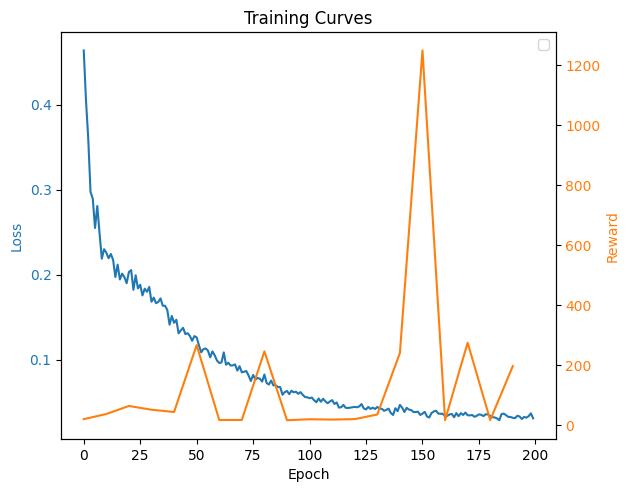

In [49]:
plot_training_curves(losses, rewards, filename="images/training_curves.png")

We load the weights that provided the top performance and provide example simulations of their behaviour.

In [39]:
# Load the best model weights saved by early stopping
try:
    model.load_state_dict(torch.load("best_decision_transformer.pth", weights_only=True))
    print("Loaded best model weights!")
except FileNotFoundError:
    print("No best model found, using current weights.")

Loaded best model weights!


In [40]:
test_reward = simulate_behaviour(
    model=model,
    env=env,
    config=config,
)

In [41]:
print(f"Test Reward: {test_reward}")

Test Reward: 9.42697915656493


## Output Examples

We visualize four trajectories generated by the model below. 

#### Example 1

In [42]:
visualize_agent(model=model, filename="video/example1.mp4")

Saved video to video/example1.mp4


#### Example 2

In [43]:
visualize_agent(model=model, filename="video/example2.mp4")

Saved video to video/example2.mp4


#### Example 3

In [44]:
visualize_agent(model=model, filename="video/example3.mp4")

Saved video to video/example3.mp4


#### Example 4

In [45]:
visualize_agent(model=model, filename="video/example4.mp4")

Saved video to video/example4.mp4


## Results

Our task in this project was to see how effectively we could train a Decision Transformer using only Human Generated data. Our choosen problem was the ADROIT Relocation problem. In this task, the goal is to have a robotic hand pick up a ball and then drop it a specified location.

Our Decision Transformer is built on top of a Encoder module based on google's "Attention is all you need" paper, as well as examples from Udacity's course materials. Effectively, we are using the Transformers ability to generate sequences to represent a Reinforcement Learning Policy.

Our task dealt with very high dimensional spaces - the state space was 39 dimensions, while the action space was 30 dimensions. These were represented as floating point arrays of 39 and 30 dimensions respecfully. Displaying the outputs of the Decision Transformer in their raw form would not be very meaningful, so a visualization function was created. An visualized example of the models output can be seen below.

Due to the limited number of human trajectories in the dataset, the model was prone to overfitting. We employed Hindsight Experience Replay to try and mitigate this issue, as well as keeping the model lean.

Despite this, the model still seems to have overfitted in some cases. The current version of the model is unable to complete the task at hand - although it can in some cases pick up the ball as seen in the first video above. On the other "hand" the model behaviour is significantly smoother than the untrained version and does show signs of starting to solve the problem. Augmenting the data either with synthetic trajectories or further human data could help solve this issue.

In [46]:
visualize_agent(model=model, filename="video/example5.mp4")

Saved video to video/example5.mp4
